In [8]:
%load_ext autoreload    
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [9]:
import cvxpy as cp
import qutip as qt
import numpy as np
import matplotlib.pyplot as plt
import plots as plots

from spins_sdp import (
    ising_hamiltonian,
    magnetization_qutip,
    gibbs_state_from_spectrum,
    npa_level,
    moment_matrix_dict,
    build_sdp_variables,
    dict_to_cvxpy_matrix_from_expr,
    ising_energy_expr,
    average_magnetization,
    ising_pauli_symbolic_terms,
    build_diagonality_constraints,
    build_lambda_matrix,
)

from tools import *
from spins_sdp.basis_builder import *

## 1. Exact Diagonalization

In [3]:
# Model parameters
N = 2
J = 1.0
h = 0
k = 0
boundary = "periodic"
beta = 1.0
axis = 'z'

# create hamiltonian
H = ising_hamiltonian(N, J, h, k)
eigenvalues, eigenstates = H.eigenstates()

# Ground state
E0 = eigenvalues[0]
psi0 = eigenstates[0]

## 2. SDP Relaxation (Ground State Energy)

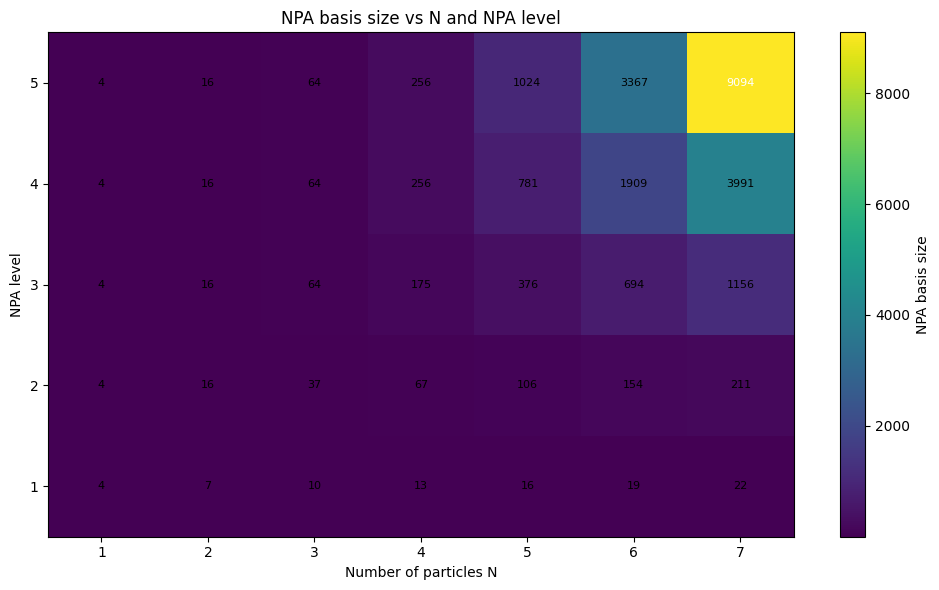

In [5]:
plots.npa_basis_size_heatmap(N=7, max_NPA_level=5)


Computed E_lb/N from function: -0.9999999999996102
Exact E0/N: -1.0


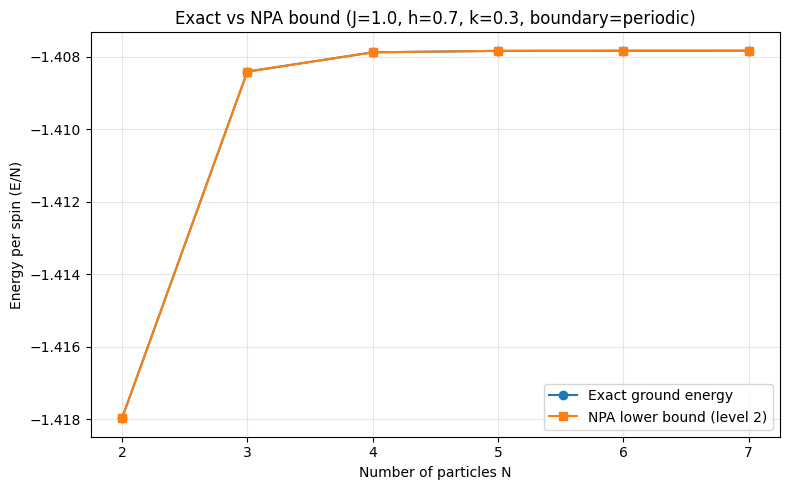

c:\Users\lmatos\Desktop\code\SpinsSDP\plots.py:133: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  plt.yscale("log")


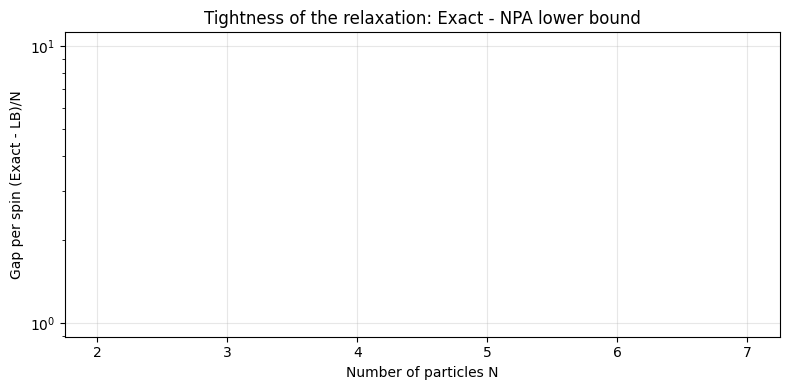

In [44]:
# SDP parameters
NPA_level = 2
N = 2
solver = "MOSEK"

# Tighter Mosek tolerances to reduce gap issues
solver_opts = {
    "mosek_params": {
        "MSK_DPAR_INTPNT_CO_TOL_REL_GAP": 1e-12,
        "MSK_DPAR_INTPNT_CO_TOL_PFEAS": 1e-12,
        "MSK_DPAR_INTPNT_CO_TOL_DFEAS": 1e-12,
    },
}

exact_E = exact_ground_state_eigenpair(H)[0]

E_lb_val = npa_lb_energy(
    J=J, h=h, k=k,
    N=N,
    NPA_level=NPA_level,
    solver=solver,
    boundary=boundary,
    solver_opts=solver_opts,
 )

print(f"Computed E_lb/N from function: {E_lb_val/N}")
print(f"Exact E0/N: {exact_E/N}")


Ns, E_exact, E_lb = plots.plot_exact_vs_npa_energy_vs_N(
    N_values=range(2, 8),
    J=1.0, h=0.7, k=0.3,
    NPA_level=2,
    boundary="periodic",
    solver=solver,
    solver_opts=solver_opts,
    per_site=True
)   

#  Bug/Numerical error somewhere since the NPA lower bound is above the exact energy for some N.


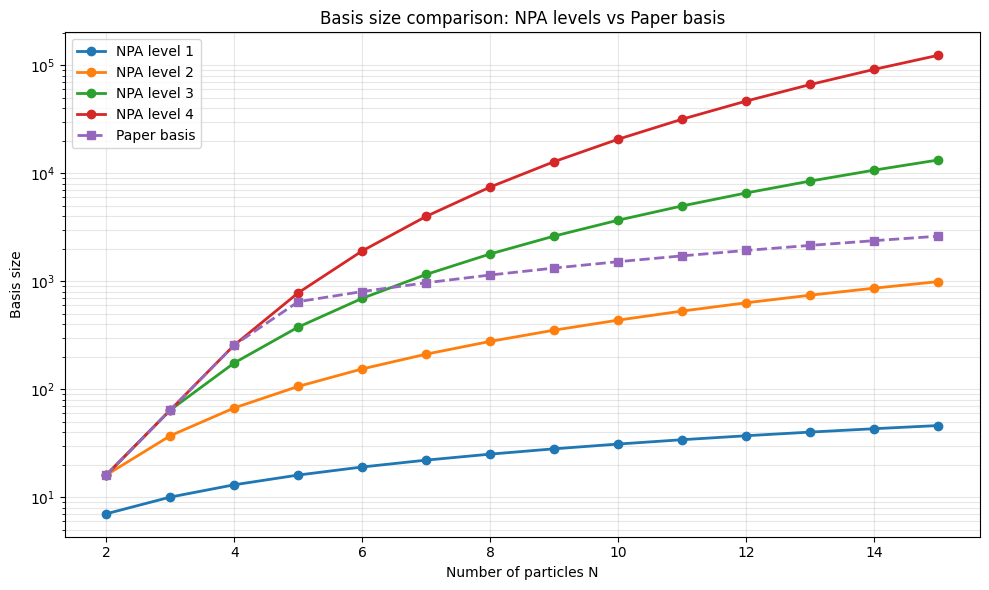

In [43]:
basis_comparison = plots.plot_basis_size_comparison(
    N_values=range(2, 16),
    npa_levels=[1, 2, 3, 4],
    include_paper_basis=True,
    logy=True,
)

We see that the paper basis only beats NPA level 3 at N=7

In [6]:
exact_data = benchmark_exact_diagonalization(
    N_values=range(2, 13),
    J=J, h=h, k=k,
    boundary="periodic",
    repeats=1,
)

In [7]:
npa_data_1 = benchmark_npa_relaxation(
    N_values=range(2, 25),
    NPA_level=1,
    J=J, h=h, k=k,
    boundary="periodic",
    solver="MOSEK",
    repeats=1,
)

In [8]:
npa_data_2 = benchmark_npa_relaxation(
    N_values=range(2, 8),
    NPA_level=2,
    J=J, h=h, k=k,
    boundary="periodic",
    solver="MOSEK",
    repeats=1,
)

In [48]:
npa_data_3 = benchmark_npa_relaxation(
    N_values=range(2, 7),
    NPA_level=3,
    J=J, h=h, k=k,
    boundary="periodic",
    solver="MOSEK",
    repeats=1,
)

In [ ]:
paper_data = benchmark_relaxation(
    N_values=range(2, 5),
    basis_fn=lambda N: generate_heisenberg_paper_basis(N=N),
    operator_fn=lambda N: ising_operator(N=N, J=J, h=h, k=k, boundary="periodic"),
    sense="min",
    solver="MOSEK",
    repeats=1
)

Paper basis benchmark completed
N values: [2 3 4]
Objective values: [-2. -3. -4.]


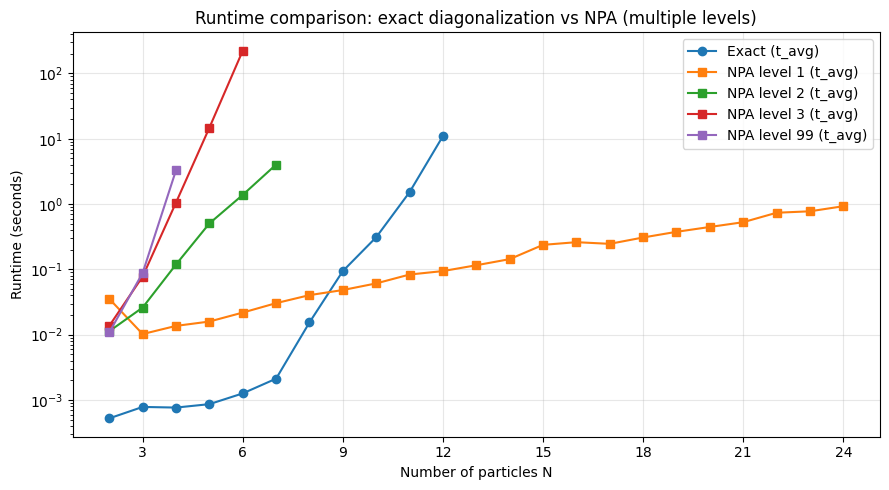

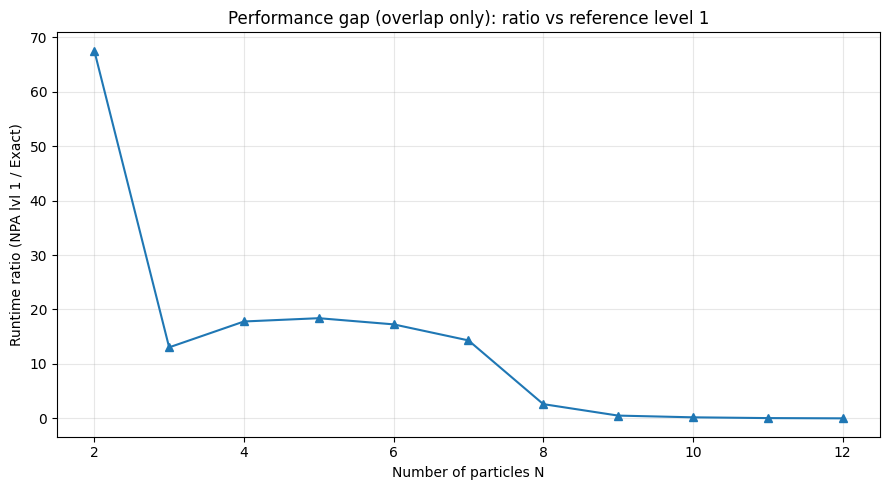

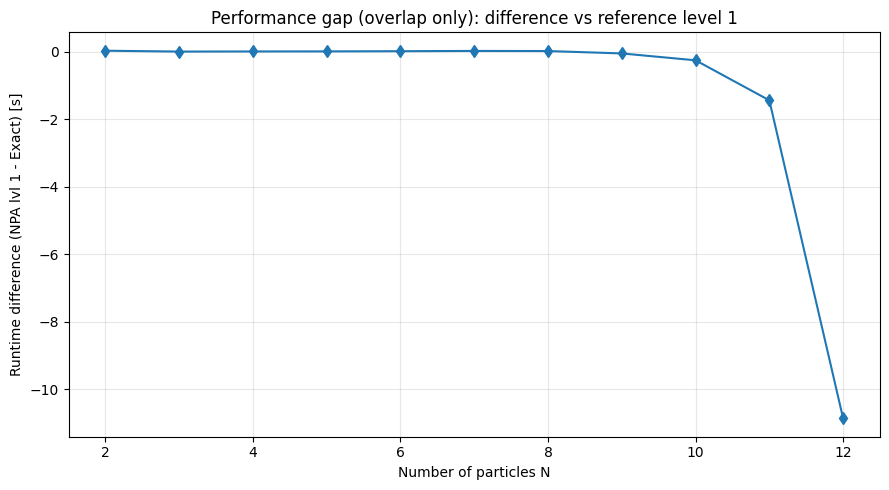

In [49]:
npa_data_by_level = {
    1: npa_data_1,
    2: npa_data_2,
    3: npa_data_3,
    99: paper_data
}

out = plots.plot_runtime_comparison_multi_levels(
    exact_data=exact_data,
    npa_data_by_level=npa_data_by_level,
    levels=[1,2,3,99],
    use="t_avg",
    logy=True,
)

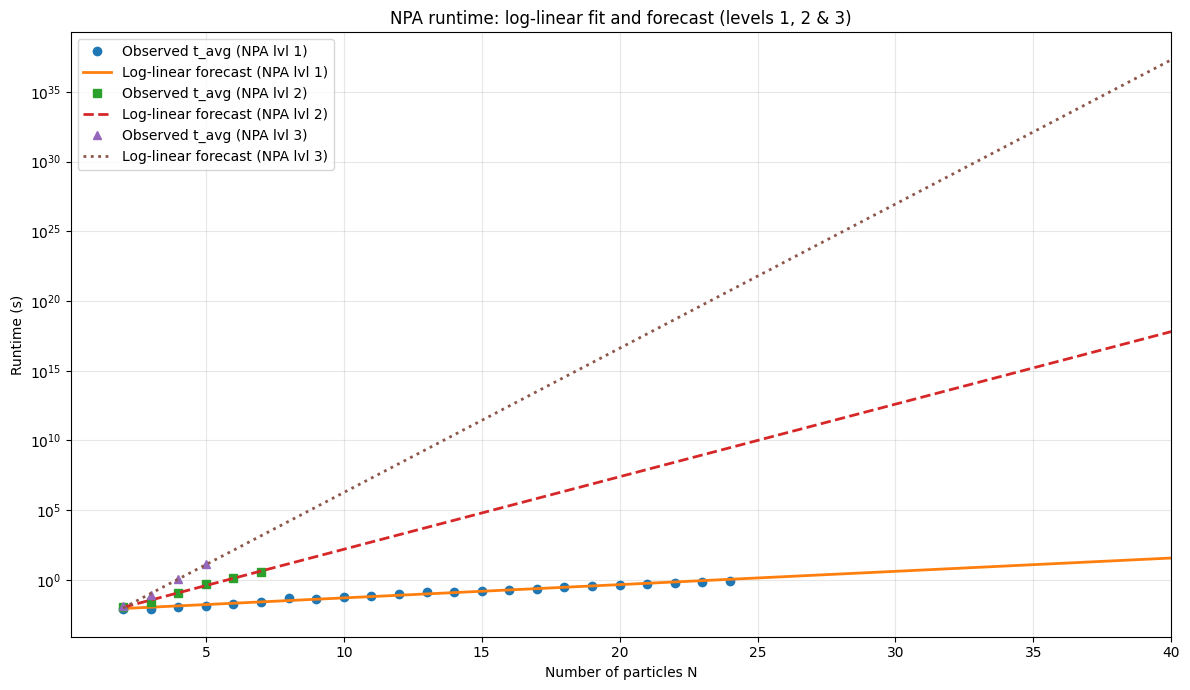

NPA Level 1:
  Fit: log t = 0.219608 * N + -5.18811
  R^2 (log-scale): 0.98423
  Forecast at N=10: 5.019e-02 s (0.00 min)
  Forecast at N=20: 4.511e-01 s (0.01 min)
  Forecast at N=30: 4.056e+00 s (0.07 min)
  Forecast at N=40: 3.646e+01 s (0.61 min)

NPA Level 2:
  Fit: log t = 1.1986 * N + -6.94529
  R^2 (log-scale): 0.99483
  Forecast at N=10: 1.546e+02 s (2.58 min)
  Forecast at N=20: 2.481e+07 s (413498.55 min)
  Forecast at N=30: 3.982e+12 s (66364664249.28 min)
  Forecast at N=40: 6.391e+17 s (10651231304749848.00 min)

NPA Level 3:
  Fit: log t = 2.38273 * N + -9.40806
  R^2 (log-scale): 0.99347
  Forecast at N=10: 1.829e+06 s (30480.93 min)
  Forecast at N=20: 4.076e+16 s (679325893475188.00 min)
  Forecast at N=30: 9.084e+26 s (15140079142455632738648064.00 min)
  Forecast at N=40: 2.025e+37 s (337425672481297131972895267369254912.00 min)


In [31]:
# Log-linear regression on NPA runtimes (t_avg) and forecast to N=40
import numpy as np
import matplotlib.pyplot as plt

# --- NPA Level 1 ---
N_obs_1 = np.array(npa_data_1["N"], dtype=float)
t_obs_1 = np.array(npa_data_1["t_avg"], dtype=float)

mask_1 = t_obs_1 > 0
N_obs_1 = N_obs_1[mask_1]
t_obs_1 = t_obs_1[mask_1]

coef_1 = np.polyfit(N_obs_1, np.log(t_obs_1), 1)
a_1, b_1 = coef_1
predict_1 = lambda N: np.exp(a_1 * N + b_1)

log_pred_1 = a_1 * N_obs_1 + b_1
log_true_1 = np.log(t_obs_1)
ss_res_1 = np.sum((log_true_1 - log_pred_1) ** 2)
ss_tot_1 = np.sum((log_true_1 - np.mean(log_true_1)) ** 2)
r2_1 = 1 - ss_res_1 / ss_tot_1 if ss_tot_1 > 0 else np.nan

N_fore_1 = np.arange(int(N_obs_1.min()), 41, dtype=float)
t_fore_1 = predict_1(N_fore_1)

# --- NPA Level 2 ---
N_obs_2 = np.array(npa_data_2["N"], dtype=float)
t_obs_2 = np.array(npa_data_2["t_avg"], dtype=float)

mask_2 = t_obs_2 > 0
N_obs_2 = N_obs_2[mask_2]
t_obs_2 = t_obs_2[mask_2]

coef_2 = np.polyfit(N_obs_2, np.log(t_obs_2), 1)
a_2, b_2 = coef_2
predict_2 = lambda N: np.exp(a_2 * N + b_2)

log_pred_2 = a_2 * N_obs_2 + b_2
log_true_2 = np.log(t_obs_2)
ss_res_2 = np.sum((log_true_2 - log_pred_2) ** 2)
ss_tot_2 = np.sum((log_true_2 - np.mean(log_true_2)) ** 2)
r2_2 = 1 - ss_res_2 / ss_tot_2 if ss_tot_2 > 0 else np.nan

N_fore_2 = np.arange(int(N_obs_2.min()), 41, dtype=float)
t_fore_2 = predict_2(N_fore_2)

# --- NPA Level 3 ---
N_obs_3 = np.array(npa_data_3["N"], dtype=float)
t_obs_3 = np.array(npa_data_3["t_avg"], dtype=float)

mask_3 = t_obs_3 > 0
N_obs_3 = N_obs_3[mask_3]
t_obs_3 = t_obs_3[mask_3]

coef_3 = np.polyfit(N_obs_3, np.log(t_obs_3), 1)
a_3, b_3 = coef_3
predict_3 = lambda N: np.exp(a_3 * N + b_3)

log_pred_3 = a_3 * N_obs_3 + b_3
log_true_3 = np.log(t_obs_3)
ss_res_3 = np.sum((log_true_3 - log_pred_3) ** 2)
ss_tot_3 = np.sum((log_true_3 - np.mean(log_true_3)) ** 2)
r2_3 = 1 - ss_res_3 / ss_tot_3 if ss_tot_3 > 0 else np.nan

N_fore_3 = np.arange(int(N_obs_3.min()), 41, dtype=float)
t_fore_3 = predict_3(N_fore_3)

# --- Plot all three (up to N=40) ---
plt.figure(figsize=(12, 7))
plt.plot(N_obs_1, t_obs_1, "o", label="Observed t_avg (NPA lvl 1)")
plt.plot(N_fore_1, t_fore_1, "-", label="Log-linear forecast (NPA lvl 1)", linewidth=2)

plt.plot(N_obs_2, t_obs_2, "s", label="Observed t_avg (NPA lvl 2)")
plt.plot(N_fore_2, t_fore_2, "--", label="Log-linear forecast (NPA lvl 2)", linewidth=2)

plt.plot(N_obs_3, t_obs_3, "^", label="Observed t_avg (NPA lvl 3)")
plt.plot(N_fore_3, t_fore_3, ":", label="Log-linear forecast (NPA lvl 3)", linewidth=2)

plt.yscale("log")
plt.xlabel("Number of particles N")
plt.ylabel("Runtime (s)")
plt.title("NPA runtime: log-linear fit and forecast (levels 1, 2 & 3)")
plt.grid(True, which="both", alpha=0.3)
plt.legend()
plt.xlim([None, 40])
plt.tight_layout()
plt.show()

print("=" * 70)
print("NPA Level 1:")
print(f"  Fit: log t = {a_1:.6g} * N + {b_1:.6g}")
print(f"  R^2 (log-scale): {r2_1:.5f}")
for N in [10, 20, 30, 40]:
    print(f"  Forecast at N={N}: {predict_1(N):.3e} s ({predict_1(N)/60:.2f} min)")

print("\nNPA Level 2:")
print(f"  Fit: log t = {a_2:.6g} * N + {b_2:.6g}")
print(f"  R^2 (log-scale): {r2_2:.5f}")
for N in [10, 20, 30, 40]:
    print(f"  Forecast at N={N}: {predict_2(N):.3e} s ({predict_2(N)/60:.2f} min)")

print("\nNPA Level 3:")
print(f"  Fit: log t = {a_3:.6g} * N + {b_3:.6g}")
print(f"  R^2 (log-scale): {r2_3:.5f}")
for N in [10, 20, 30, 40]:
    print(f"  Forecast at N={N}: {predict_3(N):.3e} s ({predict_3(N)/60:.2f} min)")
print("=" * 70)


# Paper results

### Heisenberg Chain
$$\mathcal{H}=\frac{1}{4} \sum_{i=1}^N \sum_{a\in\{x,y,z\}} \sigma_i^a \sigma_{i+1}^a$$

### Monomials in the basis
$$1, \,\, \sigma_i^a, \,\, \sigma_i^a\sigma_{i+j}^b, \,\, \sigma_i^a \sigma_{i+1}^b \sigma_{i+2}^c, \,\, \sigma_i^a \sigma_{i+1}^b \sigma_{i+2}^c \sigma_{i+3}^d, \quad i\in\{1,\cdots,N\}, \,\, j\in\{1,\cdots r\}, \,\, a,b,c,d\in\{x,y,z\}$$

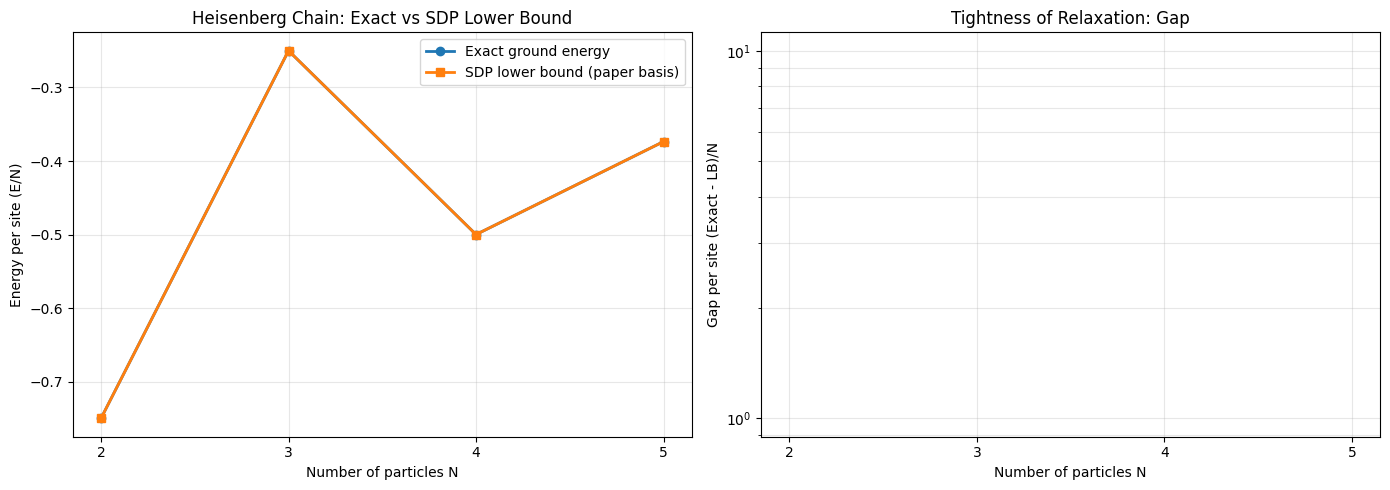

Heisenberg Chain (Paper Case B) - Exact vs SDP Comparison
N        Exact E         SDP LB          Gap             Gap/N          
--------------------------------------------------------------------------------
2        -1.50000000     -1.50000000     -1.77924786e-10 -8.89623930e-11
3        -0.75000000     -0.75000000     -8.68946359e-10 -2.89648786e-10
4        -2.00000000     -2.00000000     -9.10382880e-15 -2.27595720e-15
5        -1.86803399     -1.86803399     -4.70823380e-12 -9.41646761e-13


In [ ]:
from plots import plot_paper_heisenberg_results

N_values = range(2, 6)

heisenberg_data = plot_paper_heisenberg_results(
    N_values=N_values,
    boundary="periodic",  # Paper uses periodic boundary conditions
    solver="MOSEK",
    mosek_tol=1e-9,
    per_site=True,
)

Up until $N=10$, $E_{exact}=E_{SDP}$ in the paper, so the results are consistent for low $N$. For $N=5$, this took 14mins to run. Qualitatively, we see through printing each stage that what takes the longest is by far solving the SDP.

### Heisenberg Chain with second-neighbour couplings
$$\mathcal{H} = (1/4) \sum_{i=1}^{N} \sum_{a \in \{x,y,z\}} [\sigma_i^a \sigma_{i+1}^a + J_2 \sigma_i^a \sigma_{i+2}^a]$$

### Monomials in the basis
For $J_2\leq 1$, we take
$$1, \,\, \sigma_i^a, \,\, \sigma_i^a\sigma_{i+j}^b, \,\, \sigma_i^a \sigma_{i+1}^b \sigma_{i+2}^c, \,\, \sigma_i^a \sigma_{i+1}^b \sigma_{i+2}^c \sigma_{i+3}^d, \quad i\in\{1,\cdots,N\}, \,\, j\in\{1,\cdots r\}, \,\, a,b,c,d\in\{x,y,z\}$$
For $J_2 > 1$, we take
$$1, \,\, \sigma_i^a, \,\, \sigma_i^a \sigma_{i+j}^b, \,\, \sigma_i^a \sigma_{i+2}^b \sigma_{i+4}^c, \,\, \sigma_i^a \sigma_{i+1}^b \sigma_{i+2}^c \sigma_{i+3}^d, \quad i\in\{1,\cdots,N\}, \,\, j\in\{1,\cdots r\}, \,\, a,b,c,d\in\{x,y,z\}$$

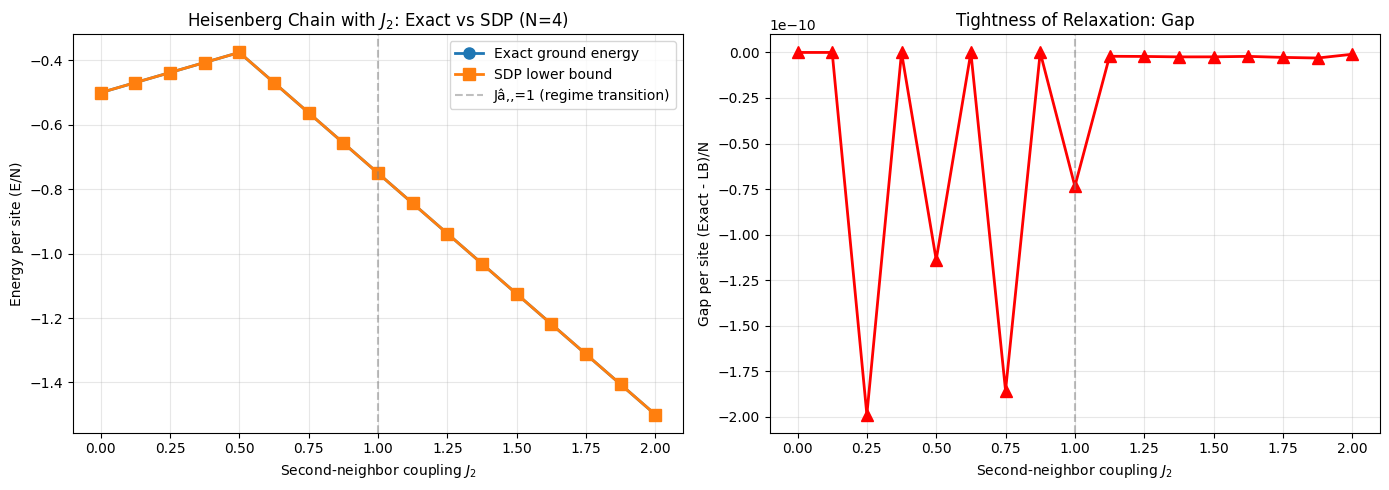

Heisenberg Chain with J2 (Paper Case C) - N=4 - Exact vs SDP Comparison
J2         Exact E         SDP LB          Gap             Gap/N           Regime         
----------------------------------------------------------------------------------------------------
0.000      -2.00000000     -2.00000000     -9.10382880e-15 -2.27595720e-15 Weak (J2<=1)   
0.125      -1.87500000     -1.87500000     -9.10382880e-15 -2.27595720e-15 Weak (J2<=1)   
0.250      -1.75000000     -1.75000000     -7.95183475e-10 -1.98795869e-10 Weak (J2<=1)   
0.375      -1.62500000     -1.62500000     -7.10542736e-15 -1.77635684e-15 Weak (J2<=1)   
0.500      -1.50000000     -1.50000000     -4.55318894e-10 -1.13829723e-10 Weak (J2<=1)   
0.625      -1.87500000     -1.87500000     -1.08801856e-14 -2.72004641e-15 Weak (J2<=1)   
0.750      -2.25000000     -2.25000000     -7.42326645e-10 -1.85581661e-10 Weak (J2<=1)   
0.875      -2.62500000     -2.62500000     -9.76996262e-15 -2.44249065e-15 Weak (J2<=1)   
1.000   

In [21]:
from plots import plot_heisenberg_j2_vs_coupling

# Include values across weak (J2 <= 1) and strong (J2 > 1) regimes
J2_values = np.linspace(0.0, 2.0, 17) # 0, 0.125, 0.25, ..., 2.0  

heisenberg_j2_data = plot_heisenberg_j2_vs_coupling(
    N=4,
    J2_values=J2_values,
    boundary="periodic",  # Paper uses periodic boundary conditions
    solver="MOSEK",
    mosek_tol=1e-9,
    per_site=True,
)

Seems consistent with the paper, qualitatively: A concave curve peaked at $J_2=0.5$. In the paper, they run it for $N=40$, which is just impossible here.